In [1]:
# Colab already has most of these, but keep it explicit
!pip install h5py seaborn


In [2]:
# Upload kaggle.json when prompted
from google.colab import files
files.upload()


Saving archive (20).zip to archive (20).zip


In [3]:
!kaggle datasets download -d daavoo/archive
!unzip archive\ \(20\).zip -d 3d-mnist


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
Archive:  archive (20).zip
  inflating: 3d-mnist/full_dataset_vectors.h5  
  inflating: 3d-mnist/plot3D.py      
  inflating: 3d-mnist/test_point_clouds.h5  
  inflating: 3d-mnist/train_point_clouds.h5  
  inflating: 3d-mnist/voxelgrid.py   



========== Fold 1 ==========
Epoch 1/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 141ms/step - accuracy: 0.3832 - loss: 1.7516 - val_accuracy: 0.1525 - val_loss: 2.6855 - learning_rate: 3.0000e-04
Epoch 2/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.6158 - loss: 1.1224 - val_accuracy: 0.1570 - val_loss: 5.9026 - learning_rate: 3.0000e-04
Epoch 3/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.6588 - loss: 0.9709 - val_accuracy: 0.1905 - val_loss: 6.0817 - learning_rate: 3.0000e-04
Epoch 4/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.7124 - loss: 0.8253 - val_accuracy: 0.2475 - val_loss: 4.5102 - learning_rate: 3.0000e-04
Epoch 5/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.7592 - loss: 0.7108 - val_accuracy: 0.5900 - val_loss: 1.4715 - learning_rate: 3.0000e-04
Epoch 6/120
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - accuracy: 0.7983 - loss: 0.6131 - val_accuracy: 0.7000 - val_loss: 0.9191 - learning_rate: 3.0000e-04
Epoch 7/12

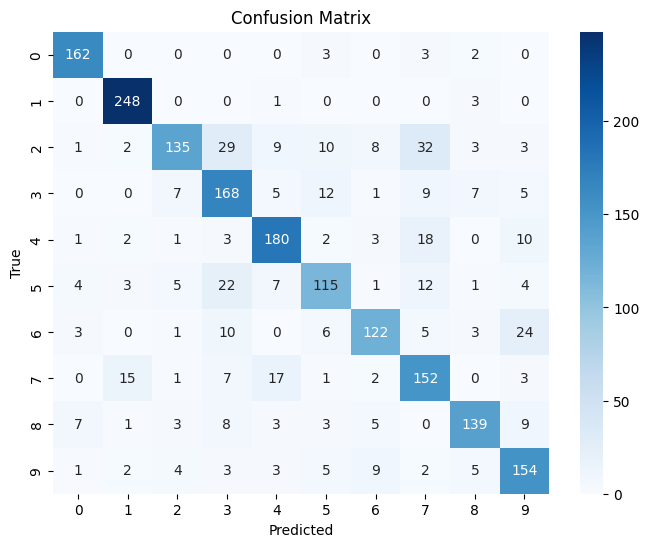

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       170
           1       0.91      0.98      0.94       252
           2       0.86      0.58      0.69       232
           3       0.67      0.79      0.72       214
           4       0.80      0.82      0.81       220
           5       0.73      0.66      0.69       174
           6       0.81      0.70      0.75       174
           7       0.65      0.77      0.71       198
           8       0.85      0.78      0.82       178
           9       0.73      0.82      0.77       188

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.78      2000
weighted avg       0.79      0.79      0.79      2000



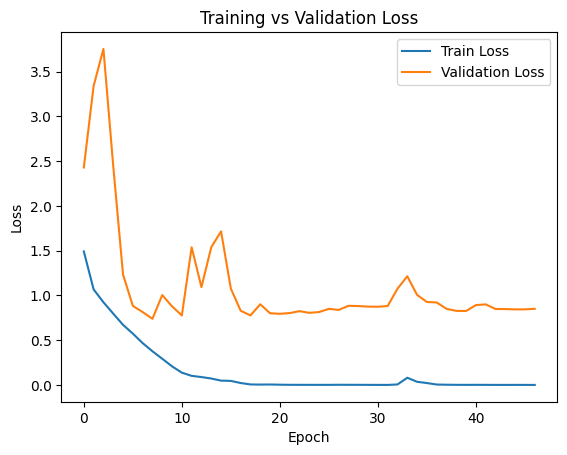

In [4]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D,
    Dense, BatchNormalization, Dropout,
    GlobalAveragePooling3D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ================== Load Dataset ==================
with h5py.File('/content/3d-mnist/full_dataset_vectors.h5', 'r') as f:
    X_train_raw = f["X_train"][:].astype("float32")
    X_test_raw  = f["X_test"][:].astype("float32")
    y_train_labels = f["y_train"][:]
    y_test_labels  = f["y_test"][:]

# Normalize
X_train_raw /= np.max(X_train_raw)
X_test_raw  /= np.max(X_train_raw)

# Reshape to voxel grids
X_train_voxel = X_train_raw.reshape(-1, 16, 16, 16, 1)
X_test_voxel  = X_test_raw.reshape(-1, 16, 16, 16, 1)

# ================== Model Builder ==================
def build_model():
    inputs = Input(shape=(16, 16, 16, 1))

    x = Conv3D(32, 3, padding="same", activation="relu")(inputs)
    x = BatchNormalization()(x)

    x = Conv3D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(2)(x)

    x = Conv3D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    x = Conv3D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(2)(x)

    x = Conv3D(256, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    x = GlobalAveragePooling3D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    outputs = Dense(10, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ================== Stratified K-Fold CV ==================
NUM_FOLDS = 5
BATCH_SIZE = 64
EPOCHS = 120

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

cv_accuracies = []
best_epochs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_voxel, y_train_labels), 1):
    print(f"\n========== Fold {fold} ==========")

    X_train_fold, X_val_fold = X_train_voxel[train_idx], X_train_voxel[val_idx]
    y_train_fold, y_val_fold = y_train_labels[train_idx], y_train_labels[val_idx]

    model = build_model()

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[lr_scheduler, early_stopping],
        verbose=1
    )

    loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold} Validation Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)
    best_epochs.append(len(history.history["loss"]))

print("\n==============================")
print(f"Mean CV Accuracy: {np.mean(cv_accuracies):.4f}")
print(f"Std  CV Accuracy: {np.std(cv_accuracies):.4f}")

# ================== Final Training ==================
optimal_epochs = int(np.mean(best_epochs))
print(f"\nTraining final model for {optimal_epochs} epochs")

final_model = build_model()

final_model.fit(
    X_train_voxel,
    y_train_labels,
    batch_size=BATCH_SIZE,
    epochs=optimal_epochs,
    verbose=1
)

# ================== Test Evaluation ==================
loss, accuracy = final_model.evaluate(X_test_voxel, y_test_labels, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

y_pred = np.argmax(final_model.predict(X_test_voxel), axis=1)

cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test_labels, y_pred))

# ================== Loss Curve (Last Fold) ==================
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()
